In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import data
import utils
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from finetune import ViTModelTrainer
from model import ResNet50Model, MobileNetV2, ViT16

import torch
import torch.nn as nn
import numpy as np
from scipy.stats import entropy

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
def compute_entropy_of_tensor(tensor, bins=30):
    # Flatten to 1D
    arr = tensor.detach().cpu().numpy().flatten()
    # Compute histogram
    hist, _ = np.histogram(arr, bins=bins, density=True)
    hist += 1e-8  # avoid log(0)
    hist = hist / np.sum(hist)
    return entropy(hist)

def extract_conv_weights_entropy(model):
    entropies = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weights = module.weight.data  # shape: [out_ch, in_ch, kH, kW]
            for i in range(weights.shape[0]):  # for each filter
                filt = weights[i]  # shape: [in_ch, kH, kW]
                H = compute_entropy_of_tensor(filt)
                entropies.append((name, i, H))
    return entropies

In [37]:
num_class = 10
model = MobileNetV2(num_class)
best_val_file = '../../dataset/CIFAKE/models/MobileNet/realmodel_160.pt'
model.load_state_dict(torch.load(best_val_file))
entropies = extract_conv_weights_entropy(model)
df_entropy_r = pd.DataFrame(entropies, columns=['layers', 'filters', 'entropy'])
df_entropy_r['layer'] = df_entropy_r['layers'].str.replace('base_model.', '')

In [38]:
model = MobileNetV2(num_class)
best_val_file = '../../dataset/CIFAKE/models/MobileNet/fakemodel_99.pt'
model.load_state_dict(torch.load(best_val_file))
entropies = extract_conv_weights_entropy(model)
df_entropy_f = pd.DataFrame(entropies, columns=['layers', 'filters', 'entropy'])
df_entropy_f['layer'] = df_entropy_f['layers'].str.replace('base_model.', '')

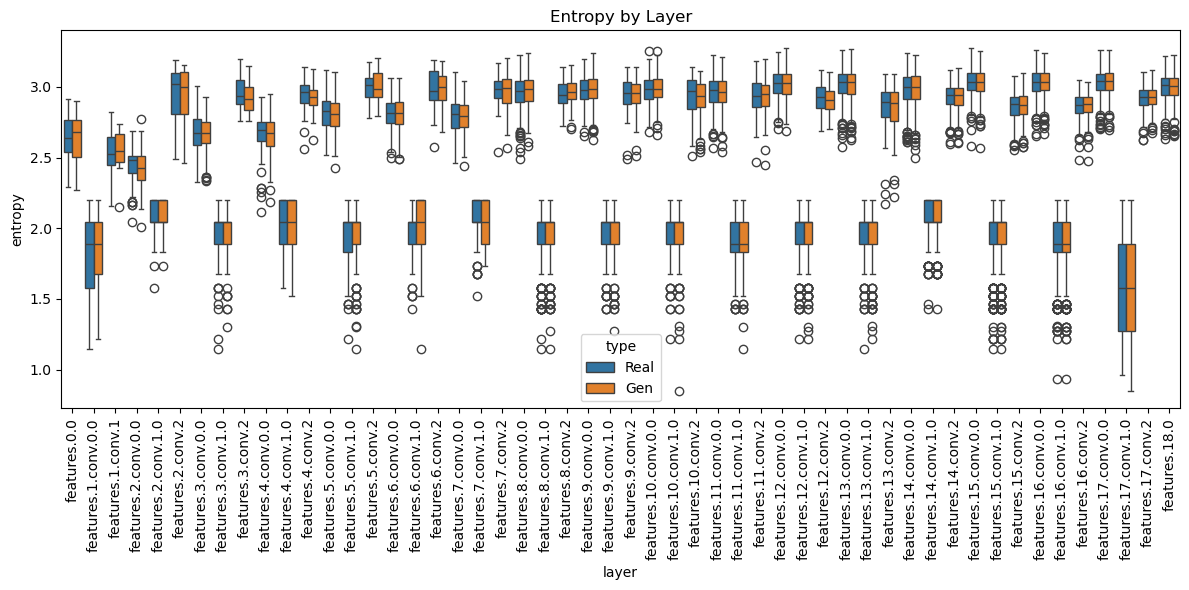

In [41]:
df_entropy_r['type'] = 'Real'
df_entropy_f['type'] = 'Gen'
df_combined = pd.concat([df_entropy_r, df_entropy_f])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x="layer", y="entropy", hue="type")
plt.xticks(rotation=90)
plt.title("Entropy by Layer")
plt.tight_layout()
plt.show()

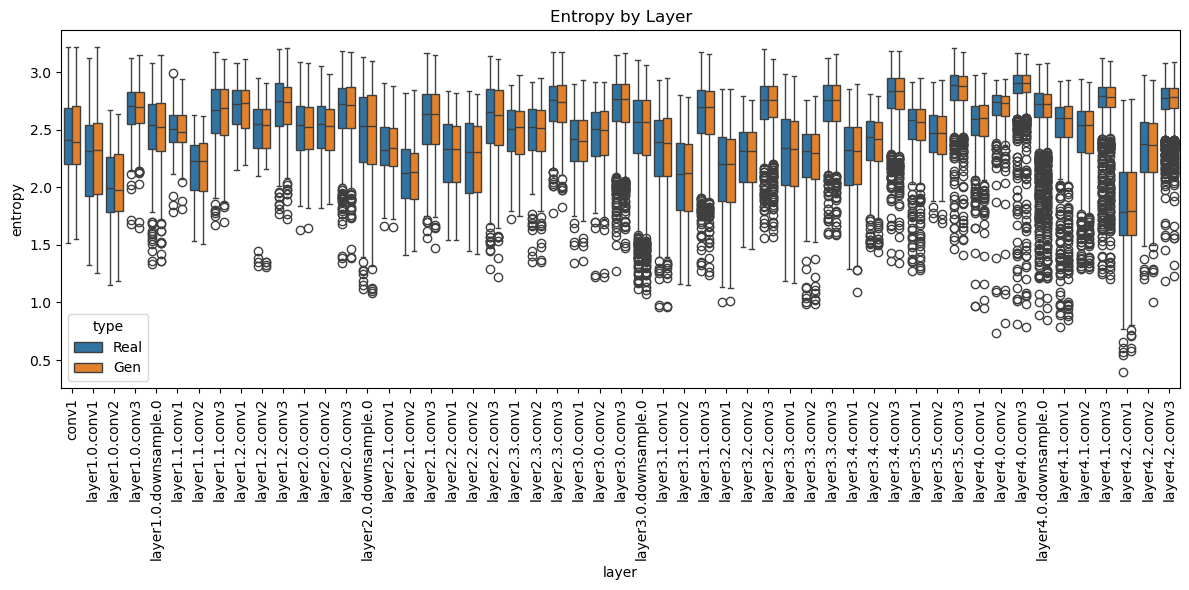

In [42]:
num_class = 10
model = ResNet50Model(num_class)
best_val_file = '../../dataset/CIFAKE/models/ResNet/realmodel_105.pt'
model.load_state_dict(torch.load(best_val_file))
entropies = extract_conv_weights_entropy(model)
df_entropy_r = pd.DataFrame(entropies, columns=['layers', 'filters', 'entropy'])
df_entropy_r['layer'] = df_entropy_r['layers'].str.replace('base_model.', '')

model = ResNet50Model(num_class)
best_val_file = '../../dataset/CIFAKE/models/ResNet/fakemodel_141.pt'
model.load_state_dict(torch.load(best_val_file))
entropies = extract_conv_weights_entropy(model)
df_entropy_f = pd.DataFrame(entropies, columns=['layers', 'filters', 'entropy'])
df_entropy_f['layer'] = df_entropy_f['layers'].str.replace('base_model.', '')

df_entropy_r['type'] = 'Real'
df_entropy_f['type'] = 'Gen'
df_combined = pd.concat([df_entropy_r, df_entropy_f])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x="layer", y="entropy", hue="type")
plt.xticks(rotation=90)
plt.title("Entropy by Layer")
plt.tight_layout()
plt.show()